In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# -----------------------------
# 1) 샘플 수
# -----------------------------
n = 5000

# -----------------------------
# 2) 설명변수 생성
# -----------------------------
age = np.random.randint(20, 66, n)                         # 20~65
income = np.random.normal(380, 120, n).round(0)           # 월소득(만원)
loan_amount = np.random.normal(2200, 750, n).round(0)     # 대출금액(만원)
credit_score = np.random.normal(670, 80, n).round(0)      # 신용점수
late_payments = np.random.poisson(1.7, n)                 # 최근 1년 연체횟수
debt_ratio = np.random.normal(42, 12, n).round(1)         # 부채비율(%)
employment_years = np.random.randint(0, 31, n)            # 재직연수
married = np.random.binomial(1, 0.52, n)                  # 혼인여부

# 현실적 범위로 자르기
income = np.clip(income, 80, 1200)
loan_amount = np.clip(loan_amount, 300, 15000)
credit_score = np.clip(credit_score, 300, 950)
debt_ratio = np.clip(debt_ratio, 1, 120)

# -----------------------------
# 3) 로짓의 "절편 제외 부분" 만들기
#    default=1이 적당히 나오게 나중에 intercept 자동 보정
# -----------------------------
eta_wo_intercept = (
    0.0007 * loan_amount
    - 0.0065 * credit_score
    + 0.60 * late_payments
    + 0.040 * debt_ratio
    - 0.030 * employment_years
    - 0.0022 * income
    - 0.12 * married
    - 0.008 * age
)

# -----------------------------
# 4) 목표 타깃 비율 설정
#    0.25면 default=1이 약 25% 정도 나오게 유도
# -----------------------------
target_rate = 0.25

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# intercept를 이분탐색으로 자동 보정
low, high = -20, 20
for _ in range(100):
    mid = (low + high) / 2
    p = sigmoid(mid + eta_wo_intercept).mean()
    if p < target_rate:
        low = mid
    else:
        high = mid

intercept = (low + high) / 2
prob = sigmoid(intercept + eta_wo_intercept)
default = np.random.binomial(1, prob, n)

loan_df = pd.DataFrame({
    "age": age,
    "income": income,
    "loan_amount": loan_amount,
    "credit_score": credit_score,
    "late_payments": late_payments,
    "debt_ratio": debt_ratio,
    "employment_years": employment_years,
    "married": married,
    "default": default
})

# -----------------------------
# 5) 이상치 삽입
# -----------------------------
outlier_idx = np.random.choice(loan_df.index, size=80, replace=False)

loan_df.loc[outlier_idx[:12], "income"] = [5, 10, 20, 1800, 2200, 3000, 4000, 2, 15, 2500, 3500, 5000]
loan_df.loc[outlier_idx[12:24], "loan_amount"] = [50, 100, 18000, 22000, 30000, 50000, 80, 120, 27000, 35000, 45000, 60000]
loan_df.loc[outlier_idx[24:36], "credit_score"] = [120, 180, 220, 990, 1020, 1100, 150, 200, 980, 1050, 50, 1150]
loan_df.loc[outlier_idx[36:48], "debt_ratio"] = [-20, -5, 150, 180, 250, -10, 300, 170, 140, -15, 210, 260]
loan_df.loc[outlier_idx[48:60], "late_payments"] = [12, 15, 18, 20, 25, 30, 14, 16, 22, 27, 35, 40]
loan_df.loc[outlier_idx[60:72], "employment_years"] = [-1, -3, 40, 45, 60, 80, -5, 50, 70, -2, 55, 100]
loan_df.loc[outlier_idx[72:80], "age"] = [5, 10, 90, 110, 3, 95, 120, 8]

# -----------------------------
# 6) 결측치 삽입
# -----------------------------
missing_plan = {
    "income": 120,
    "loan_amount": 100,
    "credit_score": 140,
    "debt_ratio": 120,
    "employment_years": 90
}

for col, m in missing_plan.items():
    miss_idx = np.random.choice(loan_df.index, size=m, replace=False)
    loan_df.loc[miss_idx, col] = np.nan

# -----------------------------
# 7) 중복 행 추가
# -----------------------------
dup_rows = loan_df.sample(50, random_state=123)
loan_df = pd.concat([loan_df, dup_rows], ignore_index=True)

# -----------------------------
# 8) 저장
# -----------------------------
loan_df.to_csv("loan_default_sample_5000.csv", index=False)

# -----------------------------
# 9) 확인
# -----------------------------
print("shape:", loan_df.shape)
print("\ndefault 개수:")
print(loan_df["default"].value_counts())
print("\ndefault 비율:")
print(loan_df["default"].value_counts(normalize=True))
print("\n결측치 개수:")
print(loan_df.isnull().sum())
print("\n중복 행 수:")
print(loan_df.duplicated().sum())
print("\nintercept:", intercept)

loan_df.to_csv('loan_customer_data.csv', encoding='utf-8', index=False)

C:\Users\박중현\AppData\Local\Temp\ipykernel_18008\2214304845.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[12, 15, 18, 20, 25, 30, 14, 16, 22, 27, 35, 40]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  loan_df.loc[outlier_idx[48:60], "late_payments"] = [12, 15, 18, 20, 25, 30, 14, 16, 22, 27, 35, 40]
C:\Users\박중현\AppData\Local\Temp\ipykernel_18008\2214304845.py:89: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1, -3, 40, 45, 60, 80, -5, 50, 70, -2, 55, 100]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  loan_df.loc[outlier_idx[60:72], "employment_years"] = [-1, -3, 40, 45, 60, 80, -5, 50, 70, -2, 55, 100]
C:\Users\박중현\AppData\Local\Temp\ipykernel_18008\2214304845.py:90: FutureWarning: Setting an item of incompatible dtype is depre

shape: (5050, 9)

default 개수:
default
0    3816
1    1234
Name: count, dtype: int64

default 비율:
default
0    0.755644
1    0.244356
Name: proportion, dtype: float64

결측치 개수:
age                   0
income              122
loan_amount         102
credit_score        140
late_payments         0
debt_ratio          121
employment_years     93
married               0
default               0
dtype: int64

중복 행 수:
50

intercept: 0.4422524825243619


In [ ]:
import pandas as pd

# 1.목적
#본 보고서는 고객 개인 데이터와 연체 데이터를 바탕으로 로지스틱 회귀분석을 수행, 연체여부와 연관 있는 변수를 찾아 잠재 고객 및 기대 고객의 데이터를 바탕으로 미래 연체 가능성을 예측하기 위함에 목적이 있다.

# 2.데이터 구조 파악
loan_df = pd.read_csv(r'loan_customer_data.csv', low_memory=False, encoding='utf-8')
print("칼럼:",loan_df.columns)
loan_df.head(10)
loan_df.info()
loan_df.describe()
print(loan_df['default'].value_counts())
print(loan_df['default'].mean())

# 3.데이터 전처리
#중복제거
print('제거 전 중복:', loan_df.duplicated().sum())
loan_df = loan_df.drop_duplicates(keep='first').reset_index(drop=True).copy()
print('제거 후 중복:', loan_df.duplicated().sum())

칼럼: Index(['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married', 'default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               5050 non-null   int64  
 1   income            4928 non-null   float64
 2   loan_amount       4948 non-null   float64
 3   credit_score      4910 non-null   float64
 4   late_payments     5050 non-null   int64  
 5   debt_ratio        4929 non-null   float64
 6   employment_years  4957 non-null   float64
 7   married           5050 non-null   int64  
 8   default           5050 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 355.2 KB
default
0    3816
1    1234
Name: count, dtype: int64
0.24435643564356435
제거 전 중복: 50
제거 후 중복: 0


칼럼: Index(['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married', 'default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               5050 non-null   int64  
 1   income            4928 non-null   float64
 2   loan_amount       4948 non-null   float64
 3   credit_score      4910 non-null   float64
 4   late_payments     5050 non-null   int64  
 5   debt_ratio        4929 non-null   float64
 6   employment_years  4957 non-null   float64
 7   married           5050 non-null   int64  
 8   default           5050 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 355.2 KB
default
0    3816
1    1234
Name: count, dtype: int64
0.24435643564356435
제거 전 중복: 50
제거 후 중복: 0
결측치: 546
결측치 비율: 0.1092
전처리 결측치: age                 0
income     

C:\Users\박중현\AppData\Local\Temp\ipykernel_18008\3113514499.py:63: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(len(loan_df[invalid_row]))


income
 lower: 54.00, upper: 702.00
 outlier count: 18
------------------------------
loan_amount
 lower: 216.00, upper: 4184.00
 outlier count: 25
------------------------------
late_payments
 lower: -0.50, upper: 3.50
 outlier count: 320
------------------------------
debt_ratio
 lower: 9.85, upper: 74.25
 outlier count: 33
------------------------------
employment_years
 lower: -17.50, upper: 42.50
 outlier count: 0
------------------------------


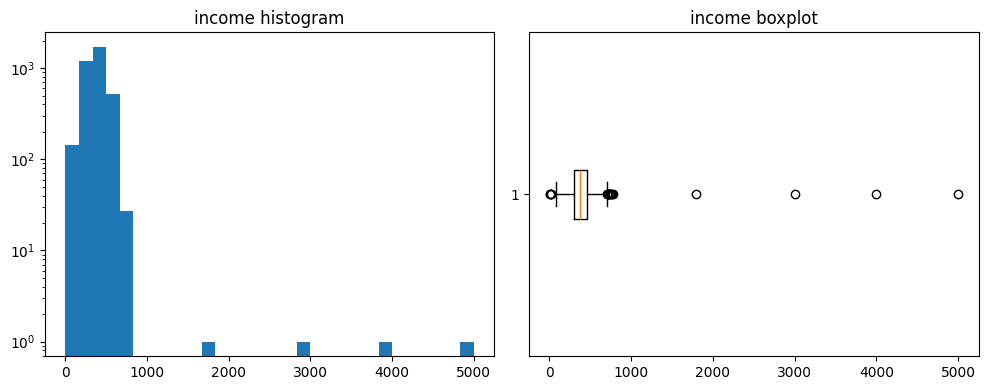

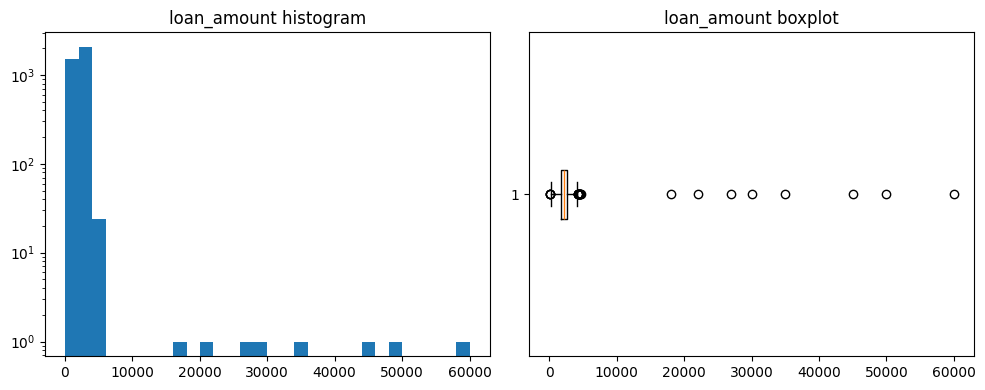

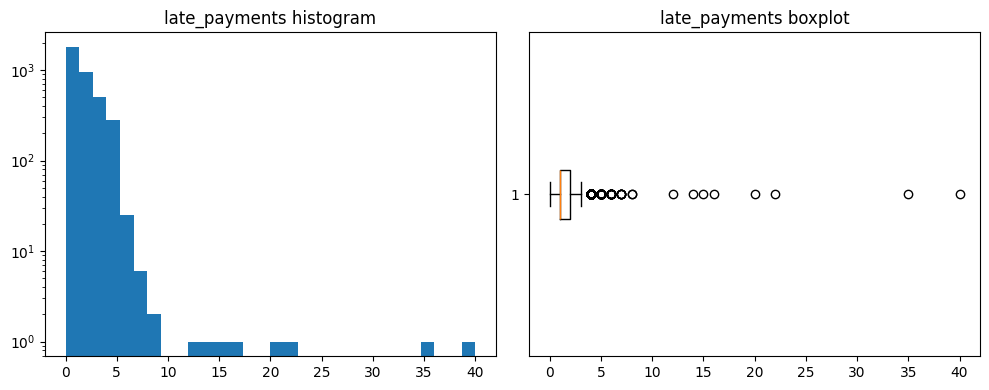

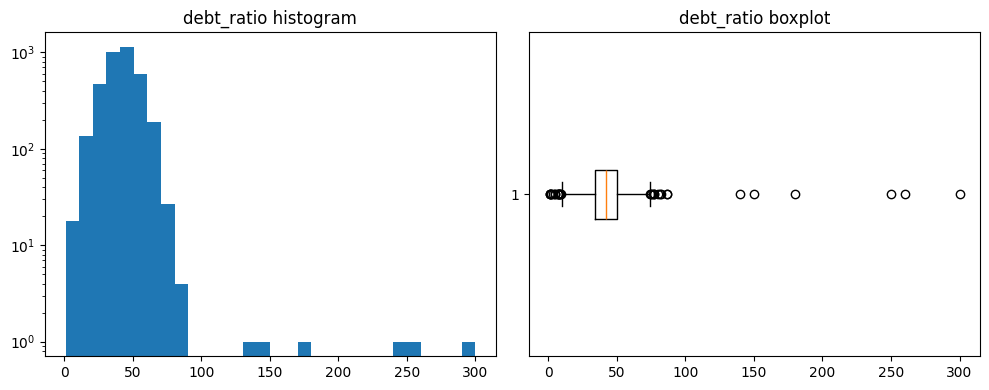

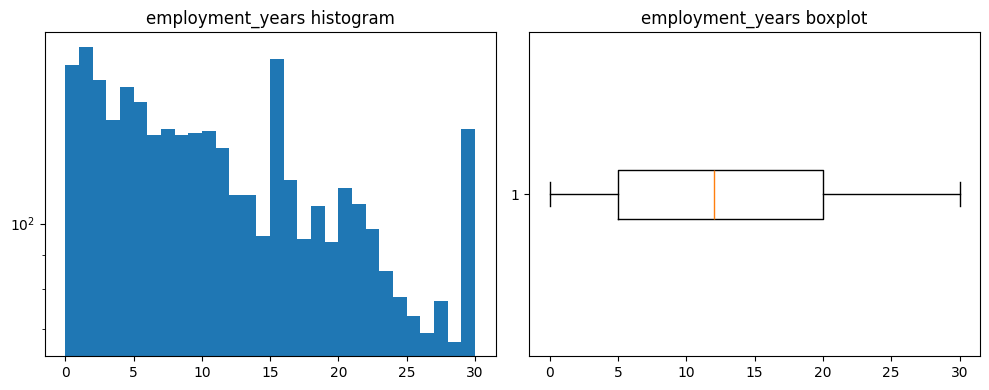

0
Index(['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married', 'default'],
      dtype='object')
  split_val: (3577, 8) (3577,)
------------------------------
  train_val: (2861, 8) (2861,)
------------------------------
validate_score: 0.7811953862285914
confusion_matrix
[[2031  113]
 [ 513  204]]

classification report
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      2144
           1       0.64      0.28      0.39       717

    accuracy                           0.78      2861
   macro avg       0.72      0.62      0.63      2861
weighted avg       0.76      0.78      0.75      2861


roc-auc: 0.7750219873436166
{'C': np.float64(5.809361216819947), 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
{'mean_fit_time': array([0.01206818, 0.00795217, 0.00841494, 0.01663508, 0.01137028,
       0.00768447, 0.0068871 , 0.03317962, 0.01163049, 0.00683222,
 

In [82]:
import numpy as np 
import pandas as pd

# 1.목적
#본 보고서는 고객 개인 데이터와 연체 데이터를 바탕으로 로지스틱 회귀분석을 수행, 연체여부와 연관 있는 변수를 찾아 잠재 고객 및 기대 고객의 데이터를 바탕으로 미래 연체 가능성을 예측하기 위함에 목적이 있다.

# 2.데이터 구조 파악
loan_df = pd.read_csv(r'loan_customer_data.csv', low_memory=False, encoding='utf-8')
print("칼럼:",loan_df.columns)
loan_df.head(10)
loan_df.info()
loan_df.describe()
print(loan_df['default'].value_counts())
print(loan_df['default'].mean())

# 3.데이터 전처리


   #중복제거
print('제거 전 중복:', loan_df.duplicated().sum())
loan_df = loan_df.drop_duplicates(keep='first').reset_index(drop=True).copy()
print('제거 후 중복:', loan_df.duplicated().sum())


   #결측치 제거
loan_df.isna().sum() #결측치 수입, 대출금액, 신용점수, 부채율, 고용연수에 전반적 고르게 분포
na_array = loan_df['income'].isna() | loan_df['loan_amount'].isna() | \
    loan_df['credit_score'].isna() | loan_df['debt_ratio'].isna() | \
        loan_df['employment_years'].isna()
print('결측치:',na_array.sum()) #총 546개의 결측치
print('결측치 비율:',na_array.mean()) #전체 샘플 대비 10% 비율로 단순 삭제의 어려움
loan_df[na_array].head(20)

cols = ['income', 'loan_amount', 'credit_score', 'debt_ratio', 'employment_years']
loan_df[cols] = loan_df[cols].fillna(loan_df[cols].median())
print('전처리 결측치:', loan_df.isna().sum()) 
# 결측치 비율은 약 10%로 단순 행 삭제 시 정보 손실이 크다고 판단, 대안으로 각 변수의 중간값으로 대채해 변수 분포 왜곡을 줄이고자 했다.


   #이상치 처리
loan_df.describe()
#도메인 오류 점검: aeg, debt, employment에서 비정상적인 수치 발견 후 제거
loan_check = loan_df.copy()
loan_check['invalid_age'] = (loan_check['age'] < 19) | (loan_check['age'] > 100)
loan_check['invalid_debt_ratio'] = (loan_check['debt_ratio']<0)
loan_check['invalid_employment_years'] = (loan_check['employment_years'] < 0) | (loan_check['employment_years'] >= loan_check['age']) \
   | (loan_check['employment_years'] >80)
   
invalid_cols = [col for col in loan_check.columns if col.startswith('invalid_')]
print(loan_check[invalid_cols].sum()) #age: 6, debt_ratio: 4, employments: 220

suspicious_rows = loan_check[loan_check[invalid_cols].any(axis=1)]
print(len(suspicious_rows)) #227개

invalid_age_row = (loan_check['age'] < 19) | (loan_check['age'] > 100)
invalid_debt_ratio_row = (loan_check['debt_ratio']<0)
invalid_employment_years_row =  (loan_check['employment_years'] < 0) | (loan_check['employment_years'] >= loan_check['age']) \
   | (loan_check['employment_years'] >80) | (loan_check['age'] - loan_check['employment_years'] < 18)

invalid_row = (invalid_age_row | invalid_debt_ratio_row | invalid_employment_years_row)

loan_df = loan_df.loc[~invalid_row]
print(len(loan_df[invalid_row]))
print(len(loan_df))
loan_df.describe() #이상없음

#이상치 제거
def iqr_outlier_bounds(series):
   q1 = series.quantile(0.25)
   q3 = series.quantile(0.75)
   iqr = q3-q1
   lower = q1 - 1.5*iqr
   upper = q3 + 1.5*iqr
   return lower, upper

def iqr_outlier_mask(series):
   lower, upper = iqr_outlier_bounds(series)
   bull_mask = (series < lower) | (series > upper)
   return bull_mask, lower, upper

outlier_columns = ['income', 'loan_amount', 'late_payments', 'debt_ratio', 'employment_years']
for col in outlier_columns:
   mask, lower, upper = iqr_outlier_mask(loan_df[col])
   print(f'{col}')
   print(f" lower: {lower:.2f}, upper: {upper:.2f}")
   print(f" outlier count: {mask.sum()}")
   print('-'*30)
# income
#  lower: 55.50, upper: 699.50
#  outlier count: 25
# ------------------------------
# loan_amount
#  lower: 212.00, upper: 4180.00
#  outlier count: 31
# ------------------------------
# late_payments
#  lower: -0.50, upper: 3.50
#  outlier count: 423
# ------------------------------
# debt_ratio
#  lower: 9.35, upper: 74.55
#  outlier count: 45
# ------------------------------
# employment_years
#  lower: -15.50, upper: 44.50
#  outlier count: 2


import matplotlib.pyplot as plt
for col in outlier_columns:
   plt.figure(figsize=(10,4))
   plt.subplot(1, 2, 1)
   plt.hist(loan_df[col], bins=30)
   plt.title(f"{col} histogram")
   plt.yscale('log')
   plt.subplot(1, 2, 2)
   plt.boxplot(loan_df[col], vert=False)
   plt.title(f"{col} boxplot")
   plt.tight_layout()
   plt.show()
mask, lower, upper = iqr_outlier_mask(loan_df['loan_amount'])
income_outliers = loan_df.loc[mask, :].sort_values(by=['loan_amount'], ascending=False)
loan_df = loan_df[~(loan_df['loan_amount'] > 10000)]
print((loan_df['loan_amount'] > 10000).sum())
#연체 횟수의 이상치는 423으로 다른 변수 대비 높은 이상치 빈도수를 보였으나, count 변수인 점을 감안할 때 자연스럽다고 판단된다. 
#연체횟수를 제외한 칼럼들의 이상치는 비교적 적은 양으로 별도의 처리가 필요하지 않을 것으로 판단되며 도메인 오류라 볼 합리적 근거가 없어 보인다. 단, 연체료의 경우 일부 수치들이 지나치게 큰 값들로 모델 학습에 방해가 될 여지가 있어 해당 열을 삭제 처리하는 것으로 이상치를 수정하였다.

   #스케일링 및 훈련세트 나누기
mean_by_default = loan_df.groupby(by='default')[loan_df.columns[0:7]].mean()
   #연체 그룹별 평균 비교 결과 연체(=1) 그룹은 평균적으로 수익, 신용점수, 고용연수가 낮았으나 유의미한 차이는 없어보이며(10%내외) 대출금액, 연체금액, 부채비율에서 높았으며 대출금액과 연채금액에서 비교적 유의미한 차이를 보였다(20-50%)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate



print(loan_df.columns)
input = loan_df[['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married']]
target = loan_df['default']
print("  split_val:", input.shape, target.shape)
print('-'*30)
train_i, test_i, train_t, test_t = train_test_split(input, target, test_size=0.2, stratify=target, random_state=42)
print("  train_val:", train_i.shape, train_t.shape)
print('-'*30)
#이는 baseline 0.749에 비해 소폭 높은 성능을 보이나 여전히 낮은 테스트 스코어로 하이퍼파라미터 튜닝 및 roc-auc와 precision, recall 성과를 확인할 필요가 있다.

#4.모델학습
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
ss = StandardScaler()
ss.fit(train_i)
train_s = ss.transform(train_i)
test_s = ss.transform(test_i)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(train_s, train_t)
print(f"validate_score: {lr.score(train_s, train_t)}")
print("confusion_matrix")
print(confusion_matrix(train_t, lr.predict(train_s)))
print()
print("classification report")
print(classification_report(train_t, lr.predict(train_s)))
print()
print("roc-auc:", roc_auc_score(train_t, lr.predict_proba(train_s)[:, 1]))
#classification report 결과, 연체 집단에 대한 precision(0.63)은 비교적 높아 연체 집단 예측은 신뢰할 수 있으나 recall(0.32)가 낮은 수준으로 분류 모델로서 성능은 아쉽다.
#accuracy는 0.79로 높으나 해당 수치는 비연체 집단에 대한 높은 예측력(precision 0.8, recall 0.94의 영향으로 보인다
#다만, roc-auc 수치 0.78로 분류 자체의 성능은 비교적 좋은 것으로 판단되며 threshold 조정을 통한 모델의 성능 제고를 기대할 수 있다.



#하이퍼파라미터 튜닝
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

splitter = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
param_dist = {
    'C': uniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']}

rs = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_dist, scoring='roc_auc',  n_iter=30, random_state=42)
rs.fit(train_s, train_t)
print(rs.best_params_)
print(rs.cv_results_)
print(np.max(rs.cv_results_['mean_test_score']))
print('-'*30)
lr_param = rs.best_estimator_
scores = cross_validate(lr_param, train_s, train_t, cv=splitter, return_train_score=True)
print(f"train_score: {np.mean(scores['train_score']).round(2)}")
print(f"val_score: {np.mean(scores['test_score']).round(2)}")
print(f"roc-auc: {roc_auc_score(train_t, lr_param.predict_proba(train_s)[:, 1])}")
print(classification_report(train_t, lr_param.predict(train_s)))
print('-'*50)
#하이퍼파라미터 튜닝 결과 최적 파라미터는 {'C': np.float64(19.968378215835976), 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}이며
#최적 파라미터로 튜닝 후 모델의 성능을 확인한 결과 train score, val score 각각 0.78, 0.77로 튜닝 전 대비 소폭 개선되었다.

lr_param.fit(train_s, train_t)
print(f"테스트 스코어: {lr_param.score(test_s, test_t)}")
print('-'*50)
#테스트 결과 0.78로 baseline 점수에 비해 높은 성과이나 분류모델로서 충분하지 않은 모델 성능을 보인다.

   #threshold 확인
train_i2, valid_i, train_t2, valid_t = train_test_split(train_i, train_t, test_size=0.25, stratify=train_t, random_state=42)
print(f'검증셋 확인:{valid_i.shape, valid_t.shape}')
print('-'*50)

ss2 = StandardScaler()
train_s2 = ss2.fit_transform(train_i2)
valid_s = ss2.transform(valid_i)
test_s = ss2.fit_transform(test_i)

lr_param.fit(train_s2, train_t2)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score
threshold = np.arange(0.1, 0.91, 0.05)
result_list = []
for th in threshold:
    valid_prob = (lr_param.predict_proba(valid_s))[:, 1]
    valid_pred = (valid_prob >= th).astype(int)
    result_list.append({'threshold': th, 'accuracy': accuracy_score(valid_t, valid_pred), 
                        'precision': precision_score(valid_t, valid_pred, zero_division=0),
                        'recall': recall_score(valid_t, valid_pred, zero_division=0), 
                        'f1': f1_score(valid_t, valid_pred, zero_division=0),
                        'roc-auc': roc_auc_score(valid_t, valid_prob)})

print(f'thresh_table 확인: ')
thresh_table = pd.DataFrame(result_list)
print(thresh_table)
print('-'*50)
# 기본 threshold=0.5에서는 연체 집단에 대한 recall이 0.3으로 낮게 나타났다. 이에 따라 예측확률 분류 기준값을 조정, threshold별 accuracy, precision, recall, F1을 비교하였다. 
# 본 분석의 목적이 연체 고위험군 고객을 선제적으로 식별하는 것이 목적이므로 recall을 우선적으로 고려하였다.
# 다만 오탐에 따른 비용도 고려하여 precision 0.5 이상을 최소 기준으로 두고 적정한 threshold를 선택하였다.
# 실제 연체 고위험군 예측의 높은 성능을 위해 precision 0.5 이상인 한에서 recall이 최대(0.61)가 되는 threshold 0.3으로 결졍하였다.
# 해당 설정은 accuracy 0.75, f1 0.55로 준수한 정확도와 precision 및 recall에서 균형있는 성능을 발휘할 수 있다고 판단된다.

# 이상의 성능 평가 결과를 종합했을 때, 
# 로지스틱 회귀는 기본적인 구분력은 확보했으나, 연체 집단 recall이 낮아 단독 실무 모형으로는 한계가 있다.
# threshold 조정과 변수 확장에도 불구하고 연체 탐지 성능이 제한적이라는 점에서, 비선형 모델과의 후속적인 비교가 필요하다.


#5. 분석결과 및 해석
    
    
    #coef
coef_table = pd.DataFrame({'feature': train_i.columns, 'coef': lr_param.coef_[0].round(3)}).sort_values('coef', ascending=False)


    #odds-ratio
coef_table['odds'] =  np.exp(coef_table['coef'])
coef_odds_table = coef_table.sort_values('odds', ascending=False)
print(f"coef_odds 테이블\n {coef_odds_table}")
print('='*50)

    #p-value
import statsmodels.api as sm
import pandas as pd
import numpy as np

# sklearn에서 사용한 같은 스케일링 데이터 사용
X_sm = pd.DataFrame(train_s, columns=train_i.columns)
X_sm = sm.add_constant(X_sm)
y_sm = train_t.reset_index(drop=True)

logit_model = sm.Logit(y_sm, X_sm)
result = logit_model.fit()

print(result.summary())
print('='*50)

#모델의 변수 별 표준화 계수(가중치)를 확인한 결과, 연체료(0.81), 대출액(0.58), 부채율(0.43)이 연체집단과 유의한(p<0.05) 양의 상관성을 보였으며
#신용점수(-0.47), 소득(-0.2), 근속연수(-0.2)는 연체집단과 유의한(p<0.05) 음의 상관성을 보였다. 특히 오즈비 기준, 연체료(+125%), 대출액(+78%), 부채율(+53%)는 연체오즈를 큰 폭으로 증가시키며
#신용점수(-38%) 연체오즈를 큰 폭으로 감소시키는 것으로 나타났으며, 연체 여부를 설명하는 핵심 변수로 판단된다.
#이는 연체, 대출, 부채가 많을 수록, 신용점수는 낮을 수록 연체 가능성이 높아진다는 합리적 직관과 일치한다. 
#반면 소득, 근속연수는 음의 상관성을 보이나 정도가 미미한 수준이며, 나이와 기혼여부는 유의하지 않아(p>0.05) 연체 여부 설명에 있어 유의한 핵심 변수라 보기 어렵다.


In [ ]:
#스케일링 및 훈련세트 나누기
mean_by_default = loan_df.groupby(by='default')[loan_df.columns[0:7]].mean()
   #연체 그룹별 평균 비교 결과 연체(=1) 그룹은 평균적으로 수익, 신용점수, 고용연수가 낮았으나 유의미한 차이는 없어보이며(10%내외) 대출금액, 연체금액, 부채비율에서 높았으며 대출금액과 연채금액에서 비교적 유의미한 차이를 보였다(20-50%)

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate



print(loan_df.columns)
input = loan_df[['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married']]
target = loan_df['default']
print("  split_val:", input.shape, target.shape)
print('-'*30)
train_i, test_i, train_t, test_t = train_test_split(input, target, test_size=0.2, stratify=target, random_state=42)
print("  train_val:", train_i.shape, train_t.shape)
print('-'*30)


#degree 테스트 결과 degree=2 부터 train_score: 0.801, test_score:0.772로 과소적합된 케이스로 보이며 degree 변수간 유의미한 차이를 보이지 않았으므로 degree=2로 선택하였다. 
#이는 baseline 0.749에 비해 소폭 높은 성능을 보이나 여전히 낮은 테스트 스코어로 하이퍼파라미터 튜닝 및 roc-auc와 precision, recall 성과를 확인할 필요가 있다.

#4.모델학습
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
ss = StandardScaler()
ss.fit(train_i)
train_s = ss.transform(train_i)
test_s = ss.transform(test_i)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(train_s, train_t)
print(f"validate_score: {lr.score(train_s, train_t)}")
print("confusion_matrix")
print(confusion_matrix(train_t, lr.predict(train_s)))
print()
print("classification report")
print(classification_report(train_t, lr.predict(train_s)))
print()
print("roc-auc:", roc_auc_score(train_t, lr.predict_proba(train_s)[:, 1]))
#classification report 결과, 연체 집단에 대한 precision(0.63)은 비교적 높아 연체 집단 예측은 신뢰할 수 있으나 recall(0.32)가 낮은 수준으로 분류 모델로서 성능은 아쉽다.
#accuracy는 0.79로 높으나 해당 수치는 비연체 집단에 대한 높은 예측력(precision 0.8, recall 0.94의 영향으로 보인다
#다만, roc-auc 수치 0.78로 분류 자체의 성능은 비교적 좋은 것으로 판단되며 threshold 조정을 통한 모델의 성능 제고를 기대할 수 있다.



#하이퍼파라미터 튜닝
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

splitter = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
param_dist = {
    'C': uniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']}

rs = RandomizedSearchCV(LogisticRegression(), param_dist, n_iter=30, random_state=42)
rs.fit(train_s, train_t)
print(rs.best_params_)
print(rs.cv_results_)
print(np.max(rs.cv_results_['mean_test_score']))
print('-'*30)
lr_param = rs.best_estimator_
scores = cross_validate(lr_param, train_s, train_t, cv=splitter, return_train_score=True)
print(f"train_score: {np.mean(scores['train_score']).round(2)}")
print(f"val_score: {np.mean(scores['test_score']).round(2)}")
print(f"roc-auc: {roc_auc_score(train_t, lr_param.predict_proba(train_s)[:, 1])}")
print(classification_report(train_t, lr_param.predict(train_s)))
print('-'*50)
#하이퍼파라미터 튜닝 결과 최적 파라미터는 {'C': np.float64(19.968378215835976), 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}이며
#최적 파라미터로 튜닝 후 모델의 성능을 확인한 결과 train score, val score 각각 0.78, 0.77로 성능의 유의미한 변화는 없었다.
#위의 성과를 종합한 결과, 로지스틱 회귀분석은 해당 모델을 적절히 설명하지 못하는 알고리즘을 판단된다.


Index(['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married', 'default'],
      dtype='object')
  split_val: (3577, 8) (3577,)
------------------------------
  train_val: (2861, 8) (2861,)
------------------------------
validate_score: 0.7811953862285914
confusion_matrix
[[2031  113]
 [ 513  204]]

classification report
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      2144
           1       0.64      0.28      0.39       717

    accuracy                           0.78      2861
   macro avg       0.72      0.62      0.63      2861
weighted avg       0.76      0.78      0.75      2861


roc-auc: 0.7750219873436166
{'C': np.float64(37.455011884736244), 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
{'mean_fit_time': array([0.00825019, 0.00814095, 0.00893812, 0.01126919, 0.00943713,
       0.01015611, 0.0103765 , 0.0075943 , 0.00937567, 0.0077086 ,
       0

In [ ]:
lr_param.fit(train_s, train_t)
print(f"테스트 스코어: {lr_param.score(test_s, test_t)}")
print('-'*50)
#테스트 결과 0.78로 baseline 점수에 비해 높은 성과이나 분류모델로서 충분하지 않은 모델 성능을 보인다.

#threshold 확인
train_i2, valid_i, train_t2, valid_t = train_test_split(train_i, train_t, test_size=0.25, stratify=train_t, random_state=42)
print(f'검증셋 확인:{valid_i.shape, valid_t.shape}')
print('-'*50)

ss2 = StandardScaler()
train_s2 = ss2.fit_transform(train_i2)
valid_s = ss2.fit_transform(valid_i)
test_s = ss2.fit_transform(test_i)

lr_param.fit(train_s2, train_t2)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score
threshold = np.arange(0.1, 0.91, 0.05)
result_list = []
for th in threshold:
    valid_prob = (lr_param.predict_proba(valid_s))[:, 1]
    valid_pred = (valid_prob >= th).astype(int)
    result_list.append({'threshold': th, 'accuracy': accuracy_score(valid_t, valid_pred), 
                        'precision': precision_score(valid_t, valid_pred, zero_division=0),
                        'recall': recall_score(valid_t, valid_pred, zero_division=0), 
                        'f1': f1_score(valid_t, valid_pred, zero_division=0),
                        'roc-auc': roc_auc_score(valid_t, valid_prob)})

print(f'thresh_table 확인: ')
thresh_table = pd.DataFrame(result_list)
print(thresh_table)
print('-'*50)
# 기본 threshold=0.5에서는 연체 집단에 대한 recall이 0.3으로 낮게 나타났다. 이에 따라 예측확률 분류 기준값을 조정,
# threshold별 accuracy, precision, recall, F1을 비교하였다. 본 분석의 목적이 연체 고위험군 고객을 분류, 예상되는 리스크와 비용을 관리하는 것임을 감안,
# 실제 연체 고위험군 예측의 높은 성능을 위해 precision 0.5 이상인 한에서 recall이 최대(0.61)가 되는 threshold 0.3으로 결졍하였다.
# 해당 설정은 accuracy 0.75, f1 0.55로 준수한 정확도와 precision 및 recall에서 균형있는 성능을 발휘할 수 있다고 판단된다.




#5. 분석결과 및 해석
    #coef
coef_table = pd.DataFrame({'feature': train_i.columns, 'coef': lr_param.coef_[0].round(3)}).sort_values('coef', ascending=False)

    #odds-ratio
coef_table['odds'] =  np.exp(coef_table['coef'])
coef_odds_table = coef_table.sort_values('odds', ascending=False)
print(f"coef_odds 테이블\n {coef_odds_table}")
print('='*50)

    #p-value
import statsmodels.api as sm
import pandas as pd
import numpy as np

# sklearn에서 사용한 같은 스케일링 데이터 사용
X_sm = pd.DataFrame(train_s, columns=train_i.columns)
X_sm = sm.add_constant(X_sm)
y_sm = train_t.reset_index(drop=True)

logit_model = sm.Logit(y_sm, X_sm)
result = logit_model.fit()

print(result.summary())
print('='*50)

#모델의 변수 별 계수(가중치)를 확인한 결과, 연체료(0.81), 대출액(0.58), 부채율(0.43)이 연체집단과 유의한(p<0.05) 양의 상관성을 보였으며
#신용점수(-0.47), 소득(-0.2), 근속연수(-0.2)는 연체집단과 유의한(p<0.05) 음의 상관성을 보였다. 특히 오즈비 기준, 연체료(+125%), 대출액(+78%), 부채율(+53%)는 연체오즈를 큰 폭으로 증가시키며
#신용점수(-38%) 연체오즈를 큰 폭으로 감소시키는 것으로 나타났으며, 연체 여부를 설명하는 핵심 변수로 판단된다.
#이는 연체, 대출, 부채가 많을 수록, 신용점수는 낮을 수록 연체 가능성이 높아진다는 합리적 직관과 일치한다. 
#반면 소득, 근속연수는 음의 상관성을 보이나 정도가 미미한 수준이며, 나이와 기혼여부는 유의하지 않아(p>0.05) 연체 여부 설명에 있어 유의한 핵심 변수라 보기 어렵다.


테스트 스코어: 0.7793296089385475
--------------------------------------------------
검증셋 확인:((716, 8), (716,))
--------------------------------------------------
thresh_table 확인: 
    threshold  accuracy  precision    recall        f1  roc-auc
0        0.10  0.441341   0.304425  0.960894  0.462366  0.78875
1        0.15  0.564246   0.353846  0.899441  0.507886  0.78875
2        0.20  0.649441   0.402174  0.826816  0.541133  0.78875
3        0.25  0.701117   0.440273  0.720670  0.546610  0.78875
4        0.30  0.751397   0.502283  0.614525  0.552764  0.78875
5        0.35  0.769553   0.541176  0.513966  0.527221  0.78875
6        0.40  0.773743   0.562963  0.424581  0.484076  0.78875
7        0.45  0.790503   0.652632  0.346369  0.452555  0.78875
8        0.50  0.786313   0.680556  0.273743  0.390438  0.78875
9        0.55  0.776536   0.672727  0.206704  0.316239  0.78875
10       0.60  0.773743   0.729730  0.150838  0.250000  0.78875
11       0.65  0.768156   0.760000  0.106145  0.186275  0.

In [76]:
#일반적으로 대출금액의 크기는 상환 부담 요인으로 작용하여, 연체여부와 양의 상관성을 보일것으로 예상되나
#개개인의 소득 수준에 따라 상환 여부와 부담 정도가 달라질 것으로 예상되므로
#본 보고서는 소득, 대출금액을 별도의 변수로 설정 및 분석에서 나아가 소득 당 대출금액을 새로운 변수로 설정하여 추가 분석을 실시했다.

loan_df2 = loan_df.copy()
print(f"소득 초과 대출 인원: {(loan_df2['income'] < loan_df2['loan_amount']).sum()}")
print(f"소득 초과 대출 비율: {((loan_df2['income'] < loan_df2['loan_amount']).sum())/len(loan_df2)}") #99%
loan_df2['loan_amount_per_income'] = (loan_df2['income'] / loan_df2['loan_amount'])
print(f"특성 별 평균: {loan_df.groupby(by=['default']).mean().round(3)}")
print('='*80)

input2 = loan_df2[['age', 'income', 'loan_amount', 'credit_score', 'late_payments',
       'debt_ratio', 'employment_years', 'married', 
       'loan_amount_per_income']]
target2 = loan_df2['default']

train_input, test_input, train_target, test_target = train_test_split(input2, target2, stratify=target2, shuffle=True, random_state=42, test_size=0.2)
print(f"훈련/테스트셋 확인: {train_input.shape, train_target.shape, test_input.shape, test_target.shape}")
print('='*80)

sss = StandardScaler()
sss.fit(train_input)
train_input_scaled = sss.transform(train_input)
test_input_scaled = sss.transform(test_input)

lr2 = LogisticRegression(random_state=42)
scores2 = cross_validate(lr2, train_input_scaled, train_target, cv=splitter, return_train_score=True)
print(f"훈련 스코어: {np.mean(scores2['train_score'].round(3))}, 테스트 스코어: {np.mean(scores2['test_score'].round(3))}")
print('='*80)

param_dist = {
    'C': uniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']}
random_search = RandomizedSearchCV(LogisticRegression(), param_dist, cv=splitter, n_iter=100, random_state=42)
random_search.fit(train_input_scaled, train_target)
print(f"최적 파라미터: {random_search.best_params_}")
print(f"최적 파라미터 테스트 스코어: {np.max(random_search.cv_results_['mean_test_score'])}")

lr_param2 = random_search.best_estimator_



소득 초과 대출 인원: 3543
소득 초과 대출 비율: 0.9904948280682135
특성 별 평균:             age   income  loan_amount  credit_score  late_payments  \
default                                                              
0        48.151  384.378     2106.491       680.193          1.500   
1        47.021  370.072     2453.946       649.559          2.358   

         debt_ratio  employment_years  married  
default                                         
0            41.100            13.002    0.532  
1            45.484            11.449    0.521  
훈련/테스트셋 확인: ((2861, 9), (2861,), (716, 9), (716,))
훈련 스코어: 0.7814000000000001, 테스트 스코어: 0.7780000000000001
최적 파라미터: {'C': np.float64(37.455011884736244), 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
최적 파라미터 테스트 스코어: 0.7780458633861775


In [80]:
train_pred = lr_param2.predict(train_input_scaled)
train_prob = lr_param2.predict_proba(train_input_scaled)[:, 1]
evaluation_table = pd.DataFrame([{'accuracy': accuracy_score(train_target, train_pred),
                                 'precision': precision_score(train_target, train_pred, zero_division=0), 
                                 'recall': recall_score(train_target, train_pred, zero_division=0),
                                 'f1': f1_score(train_target, train_pred, zero_division=0), 
                                 'roc-auc': roc_auc_score(train_target, train_prob)}])
print(f'평가 테이블')
print('-'*80)
print(evaluation_table)
print('='*80)
result = []
for threshold in np.arange(0.1, 0.9, 0.05):
    train_pred_thr = (train_prob >= threshold).astype(int)
    result.append({'threshold': threshold, 'accuracy': accuracy_score(train_target, train_pred_thr),
                                 'precision': precision_score(train_target, train_pred_thr, zero_division=0), 
                                 'recall': recall_score(train_target, train_pred_thr, zero_division=0),
                                 'f1': f1_score(train_target, train_pred_thr, zero_division=0), 
                                 'roc-auc': roc_auc_score(train_target, train_prob)})
thres_table = pd.DataFrame(result)
print('스레드홀드 테이블')
print('-'*80)
print(thres_table)
print('='*80)

print(lr_param2.score(test_input_scaled, test_target))
test_pred = (lr_param2.predict_proba(test_input_scaled)[:, 1]>=0.3).astype(int)
print(accuracy_score(test_target, test_pred))
print(classification_report(test_target, test_pred))

평가 테이블
--------------------------------------------------------------------------------
   accuracy  precision    recall        f1   roc-auc
0  0.781195   0.643533  0.284519  0.394584  0.775022
스레드홀드 테이블
--------------------------------------------------------------------------------
    threshold  accuracy  precision    recall        f1   roc-auc
0        0.10  0.445648   0.305767  0.953975  0.463101  0.775022
1        0.15  0.556099   0.348659  0.888424  0.500786  0.775022
2        0.20  0.641384   0.393227  0.793584  0.525878  0.775022
3        0.25  0.692765   0.429319  0.686192  0.528180  0.775022
4        0.30  0.744495   0.492135  0.610879  0.545115  0.775022
5        0.35  0.771409   0.545852  0.523013  0.534188  0.775022
6        0.40  0.777001   0.573284  0.430962  0.492038  0.775022
7        0.45  0.777001   0.594724  0.345886  0.437390  0.775022
8        0.50  0.781195   0.643533  0.284519  0.394584  0.775022
9        0.55  0.777351   0.669492  0.220363  0.331584  0.775022


In [91]:
import pandas as pd

def summarize_dataframe(df: pd.DataFrame) -> dict:
    return {
        "n_rows": df.shape[0],
        "n_cols": df.shape[1],
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict(),
        "missing_counts": df.isnull().sum().to_dict(),
        "duplicate_count": int(df.duplicated().sum()),
    }

def target_summary(df: pd.DataFrame, target_col: str) -> dict:
    vc = df[target_col].value_counts(dropna=False).to_dict()
    ratio = df[target_col].value_counts(normalize=True, dropna=False).to_dict()
    return {
        "value_counts": vc,
        "ratios": ratio,
    }
    
def dataframe_summarize(df: pd.DataFrame):
    import pandas as pd

def summarize_dataframe(df: pd.DataFrame, head_n: int = 5) -> None:
    print("[DataFrame]")
    print("-" * 50)
    print(df.head(head_n))
    print()

    print("[DataFrame Info]")
    print("-" * 50)
    df.info()
    print()

    print("[DataFrame Describe]")
    print("-" * 50)
    print(df.describe(include="all").T)
    print()
    
summarize_dataframe(loan_df)


[DataFrame]
--------------------------------------------------
   age  income  loan_amount  credit_score  late_payments  debt_ratio  \
0   58   176.0        581.0         766.0              5        32.0   
1   48   324.0       1727.0         556.0              3        58.5   
3   62   506.0       1149.0         728.0              2        41.7   
4   27   258.0       2804.0         640.0              1        35.5   
5   40   289.0       3051.0         589.0              3        41.9   

   employment_years  married  default  
0              18.0        1        0  
1              21.0        0        1  
3               0.0        0        0  
4               4.0        0        0  
5               5.0        0        1  

[DataFrame Info]
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 3577 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  


In [ ]:
좋아요. 먼저 **직접 해볼 수 있도록**

1. 연습용 샘플데이터,
2. 실무형 분석 흐름,
3. 해석할 때 뭘 봐야 하는지에 대한 **대략적인 가이드라인만** 드릴게요.

이번에는 일부러 **정답 코드와 해설은 빼고**, 마지막에 “나중에 확인할 체크포인트”만 적어두겠습니다.
당신이 먼저 스스로 돌려본 뒤, 원하면 다음 단계에서 **코드 + 해설지**를 드리는 방식으로 가면 됩니다.

---

# 1) 로지스틱 회귀 연습용 샘플데이터

주제는 **대출 연체 여부 예측**으로 잡겠습니다.
실무에서도 꽤 자주 보는 구조이고, 로지스틱 회귀에 잘 맞습니다.

* 종속변수(y): `default`

  * 1 = 연체 발생
  * 0 = 정상 상환

* 독립변수(X) 예시

  * `age`: 나이
  * `income`: 월소득(만원)
  * `loan_amount`: 대출금액(만원)
  * `credit_score`: 신용점수
  * `late_payments`: 최근 1년 연체 횟수
  * `debt_ratio`: 부채비율(%)
  * `employment_years`: 재직연수
  * `married`: 혼인 여부 (0/1)

아래 CSV를 그대로 복사해서 `loan_default_sample.csv`로 저장하면 됩니다.

```csv
age,income,loan_amount,credit_score,late_payments,debt_ratio,employment_years,married,default
25,220,1800,610,3,48,1,0,1
34,420,1500,720,0,28,6,1,0
29,310,2200,680,1,35,3,0,0
45,500,1200,760,0,22,12,1,0
52,390,2500,640,2,44,15,1,1
23,210,1600,590,4,52,1,0,1
40,470,1400,730,0,25,10,1,0
31,330,2000,670,1,37,5,0,0
28,260,2400,620,2,46,2,0,1
36,410,1700,710,0,30,8,1,0
50,530,1300,780,0,20,20,1,0
27,240,2100,600,3,49,2,0,1
33,360,1900,690,1,34,6,1,0
46,480,1600,740,0,27,14,1,0
38,350,2300,650,2,42,7,0,1
24,200,1700,580,4,55,1,0,1
41,450,1500,725,0,26,11,1,0
30,300,2100,660,1,39,4,0,0
55,520,1400,770,0,21,23,1,0
26,230,2500,605,3,50,2,0,1
37,390,1800,700,1,32,9,1,0
43,460,1550,735,0,24,13,1,0
32,340,1950,685,1,36,5,0,0
29,280,2350,630,2,45,3,0,1
48,510,1450,750,0,23,18,1,0
22,190,1650,570,5,58,0,0,1
35,430,1750,715,0,29,8,1,0
39,370,2250,655,2,41,7,1,1
44,490,1500,745,0,25,16,1,0
27,250,2050,615,2,47,2,0,1
31,320,1900,675,1,35,4,1,0
53,540,1350,785,0,19,25,1,0
28,270,2450,625,3,48,2,0,1
42,455,1580,728,0,27,12,1,0
34,400,1800,705,0,31,7,1,0
26,215,2200,595,4,53,1,0,1
47,495,1480,742,0,24,17,1,0
30,295,2150,650,2,40,3,0,1
36,415,1720,712,0,30,9,1,0
24,205,1750,585,4,54,1,0,1
40,440,1600,720,0,28,11,1,0
33,355,2000,688,1,34,6,1,0
29,275,2380,628,2,46,3,0,1
51,525,1380,775,0,20,22,1,0
38,365,2280,648,2,43,8,0,1
45,485,1520,738,0,26,15,1,0
27,245,2120,608,3,49,2,0,1
32,345,1920,682,1,36,5,1,0
41,448,1570,730,0,27,12,1,0
25,225,1850,600,3,50,1,0,1
```

---

# 2) 이 데이터로 뭘 해보면 좋나

당신의 목표는 단순히 “모형 돌리기”가 아니라,
**실무처럼 로지스틱 회귀를 해석하는 연습**을 하는 겁니다.

핵심 질문은 이겁니다.

> “어떤 요인이 연체 확률을 높이거나 낮추는가?”

즉,

* 어떤 변수가 중요한지
* 영향 방향이 +인지 -인지
* 그 영향이 해석 가능한지
* 모델이 실무에 쓸 만한지

를 보는 연습입니다.

---

# 3) 실무에서는 대체 어떤 과정을 거치나

보통 아래 순서로 갑니다.

## 1단계. 문제 정의

먼저 종속변수를 분명히 정의합니다.

예:

* `default=1`이 “연체 발생”인지
* 아니면 “정상 상환”인지

이걸 헷갈리면 **계수 해석 방향이 전부 뒤집힙니다.**
그래서 제일 먼저 확인해야 합니다.

이번 데이터에서는:

* `default = 1` → 연체 발생
* `default = 0` → 정상 상환

즉,

* 계수가 **양수(+)**면 연체 가능성이 커지는 방향
* 계수가 **음수(-)**면 연체 가능성이 작아지는 방향

입니다.

---

## 2단계. 데이터 구조 확인

가장 먼저 보는 것:

* 행 수, 열 수
* 결측치 유무
* 변수 타입
* 타깃 비율(0과 1이 얼마나 균형인지)

여기서 특히 중요한 건 **타깃 비율**입니다.

예:

* 0이 95%, 1이 5%면 불균형 데이터라서
* 정확도만 보고 판단하면 안 됩니다.

이번 샘플은 아주 심한 불균형은 아니게 만들었지만,
그래도 꼭 `default` 비율을 확인해보세요.

---

## 3단계. 기초 탐색(EDA)

변수별로 간단히 확인합니다.

### 연속형 변수

* 평균, 중앙값, 표준편차
* 최소/최대값
* 박스플롯, 히스토그램

예를 들어,

* 연체자 그룹의 `credit_score`가 낮은지
* 연체자 그룹의 `debt_ratio`가 높은지
* 연체자 그룹의 `late_payments`가 많은지

이런 걸 먼저 눈으로 봅니다.

### 범주형 변수

* 빈도표
* 그룹별 비율표

예:

* `married=1` 집단과 `married=0` 집단의 연체율 차이

---

## 4단계. 전처리

실무에서는 이 단계가 꽤 중요합니다.

주로 보는 것:

* 결측치 처리
* 이상치 확인
* 범주형 변수 인코딩
* 스케일링 필요 여부
* train/test 분리

이번 데이터는 연습용이라 결측치를 일부러 넣지 않았고,
`married`도 이미 0/1이라 간단합니다.

다만 연습할 때는 꼭:

* `X`와 `y` 분리
* train/test split
  이 과정은 해보세요.

---

## 5단계. 모델 적합

이제 로지스틱 회귀를 돌립니다.

보통 실무에서 두 종류 관점이 있습니다.

### A. 예측용 관점

* 테스트 성능이 어떤가
* 정확도, 정밀도, 재현율, F1, ROC-AUC
* threshold를 어떻게 둘 것인가

### B. 해석용 관점

* 어떤 변수의 계수가 유의한가
* 방향성이 논리적인가
* 오즈비(odds ratio)는 어떤 의미인가

연습에서는 **둘 다** 보되,
처음에는 해석용 관점에 더 집중하면 좋습니다.

---

# 4) 로지스틱 회귀에서 “무엇을 보고” 해석하나

핵심은 크게 5개입니다.

## 1. 계수(coefficient)의 부호

가장 먼저 보는 것은 부호입니다.

* `+`면 `default=1`일 가능성 증가
* `-`면 `default=1`일 가능성 감소

예를 들어,

* `late_payments` 계수가 `+`면
  최근 연체 횟수가 많을수록 실제 연체 가능성이 높아진다는 뜻
* `credit_score` 계수가 `-`면
  신용점수가 높을수록 연체 가능성이 낮아진다는 뜻

이건 직관과 맞는지 꼭 봐야 합니다.

---

## 2. p-value 또는 유의성

해석용 로지스틱 회귀에서는 보통 **유의성**을 봅니다.

많이 보는 기준:

* p-value < 0.05

하지만 실무에서는 이것만으로 판단하지 않습니다.

왜냐하면:

* 표본 수가 적으면 좋은 변수도 유의하지 않을 수 있고
* 표본 수가 크면 의미 없는 차이도 유의할 수 있기 때문입니다.

그래서 보통 이렇게 봅니다.

* 방향이 합리적인가
* 크기가 실무적으로 의미 있는가
* 다른 변수와 함께 봤을 때도 유지되는가

---

## 3. 오즈비(odds ratio, exp(coef))

로지스틱 회귀 해석의 핵심입니다.

계수 그 자체보다 **exp(계수)**를 많이 봅니다.

해석 방식:

* 오즈비 > 1 : 사건 발생 가능성 증가
* 오즈비 < 1 : 사건 발생 가능성 감소

예:

* `late_payments`의 오즈비가 1.8이면
  다른 조건이 같을 때, 연체 횟수 1회 증가 시 연체 오즈가 1.8배
* `credit_score`의 오즈비가 0.98이면
  점수 1점 증가할 때 연체 오즈가 0.98배

다만 1점 단위가 너무 작으면 해석이 약하니,

* 신용점수 10점 증가 기준
* 소득 100만원 증가 기준
  처럼 재해석하는 경우가 많습니다.

---

## 4. 모델 성능 지표

예측 관점에서는 이걸 봅니다.

주요 지표:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Confusion Matrix

실무에서는 특히 **Recall**과 **Precision**을 많이 봅니다.

예를 들어 연체 예측 모델이면,

* 실제 연체자를 놓치지 않는 게 중요하면 Recall 중시
* 괜히 정상 고객을 연체 위험으로 찍지 않는 게 중요하면 Precision 중시

즉,
무슨 업무인지에 따라 중요한 지표가 달라집니다.

---

## 5. 다중공선성

해석형 모델에서 중요합니다.

변수들끼리 너무 비슷하면:

* 계수 부호가 이상해질 수 있고
* p-value가 흔들릴 수 있고
* 해석이 꼬일 수 있습니다

예:

* `income`과 `debt_ratio`
* `loan_amount`와 `debt_ratio`
  같은 변수들이 서로 강하게 얽힐 수 있습니다.

그래서 실무에서는:

* 상관계수
* VIF
  를 확인합니다.

---

# 5) 어떤 변수를 중점으로 봐야 하나

이번 샘플에서는 우선 아래 변수들을 중심으로 보세요.

## 1. `late_payments`

가장 먼저 보세요.

이유:

* 직관적으로도 강한 예측 변수일 가능성이 큼
* 해석이 쉬움
* 실무적으로도 설명력이 좋음

예상:

* 값이 클수록 연체 확률 증가

---

## 2. `credit_score`

매우 중요합니다.

이유:

* 금융 실무에서 핵심 변수
* 방향성 해석이 명확함

예상:

* 점수가 높을수록 연체 확률 감소

---

## 3. `debt_ratio`

중요하게 보세요.

이유:

* 소득 대비 부채 부담을 반영
* 연체와 강한 관련 가능성 높음

예상:

* 높을수록 연체 확률 증가

---

## 4. `income`

중요하지만 단독 해석은 주의하세요.

이유:

* 소득이 높으면 상환 능력이 좋을 수 있음
* 하지만 대출 규모가 더 크면 효과가 약해질 수 있음

즉,

* `income`은 단독보다
* `loan_amount`, `debt_ratio`와 함께 볼 때 더 좋습니다.

---

## 5. `loan_amount`

이것도 중요합니다.

다만 주의:

* 대출금액이 크다고 무조건 연체는 아님
* 고소득자는 큰 대출도 감당 가능할 수 있음

그래서 보통:

* `income`과 함께 해석
* 혹은 `loan_amount / income` 같은 파생변수를 만들기도 합니다

이번엔 일단 원자료로만 해보세요.

---

## 6. `employment_years`

보조적으로 보세요.

예상:

* 재직연수가 길수록 안정적일 수 있어 연체 가능성 감소

하지만 실제로는 아주 강하지 않을 수 있습니다.

---

## 7. `married`

이 변수는 보조적입니다.

실무에선 이런 인구통계 변수는 민감할 수 있고,
설명력도 핵심 재무변수보다 약한 경우가 많습니다.

그래도 연습용으로:

* 유의한지
* 방향이 예상과 맞는지
  를 보는 정도는 좋습니다.

---

# 6) 해석할 때 조심할 점

## 1. 계수 크기만 단순 비교하지 말기

변수 단위가 다르면 계수 크기 비교가 어렵습니다.

예:

* `credit_score`는 1점 단위
* `income`은 1만원/100만원 단위처럼 해석될 수 있음

그래서

* 표준화하거나
* 오즈비를 적절한 단위로 재해석해야 합니다.

---

## 2. 유의하다고 무조건 중요한 건 아님

통계적 유의성과 실무적 중요성은 다릅니다.

예:

* p-value는 작아도 오즈비 변화가 너무 미미하면 실무적 의미는 작을 수 있습니다.

---

## 3. 인과관계처럼 말하면 안 됨

로지스틱 회귀는 기본적으로 **연관성**을 보는 도구입니다.

그래서 해석은 보통 이렇게 합니다.

* “A가 증가할수록 연체 가능성이 높아지는 경향이 있다”
* “A는 연체와 정(+)의 관련을 보인다”

이렇게 말하는 게 안전합니다.

---

## 4. 예측력과 해석력은 다를 수 있음

실무에서는 가끔:

* 예측력 좋은 모델
* 해석 쉬운 모델
  이 다를 수 있습니다.

로지스틱 회귀는 보통 **해석 친화적**이라서 많이 씁니다.

---

# 7) 당신이 직접 해볼 때 추천 순서

아래 순서대로 해보면 좋습니다.

## 1.

CSV 불러오기

## 2.

`default`의 0/1 비율 확인

## 3.

기초통계량 확인

## 4.

연체 여부별 평균 비교

예:

* 연체자(default=1) vs 정상(default=0)
* 각 변수 평균 비교

## 5.

상관관계 간단히 확인

## 6.

train/test split

## 7.

로지스틱 회귀 적합

## 8.

예측 성능 확인

* confusion matrix
* classification report
* ROC-AUC

## 9.

계수와 오즈비 해석

## 10.

어떤 변수가 핵심인지 정리

---

# 8) 스스로 해볼 때 작성해볼 만한 해석 문장 틀

결과를 본 뒤 아래 형식으로 직접 써보세요.

### 변수 해석

* `late_payments`는 연체 여부와 양(+)의 관련을 보였다.
* `credit_score`는 연체 여부와 음(-)의 관련을 보였다.
* `debt_ratio`가 높을수록 연체 가능성이 커지는 경향이 나타났다.

### 모델 해석

* 모델은 연체 여부를 일정 수준 구분했다.
* 다만 정밀도/재현율 중 어느 쪽이 더 중요한지는 업무 목적에 따라 달라진다.
* 금융 실무에서는 실제 연체자를 놓치지 않는 것이 중요할 수 있으므로 재현율도 함께 봐야 한다.

### 실무 해석

* 핵심 관리 변수는 `late_payments`, `credit_score`, `debt_ratio`로 보인다.
* `income`과 `loan_amount`는 함께 해석해야 하며, 단독 해석에는 주의가 필요하다.

---

# 9) 나중에 줄 “코드 + 해설지”의 구성 예고

당신이 먼저 해본 뒤 요청하면, 다음 단계에서 이런 식으로 드릴 수 있습니다.

* Python 코드

  * pandas로 불러오기
  * EDA
  * sklearn 로지스틱 회귀
  * statsmodels로 계수/p-value 보기
  * 오즈비 계산
  * 성능평가

* 해설지

  * 각 출력표를 어떻게 읽는지
  * 어떤 변수에 주목해야 하는지
  * 면접/과제 제출용 문장으로 어떻게 정리하는지

---

# 10) 지금 단계에서의 핵심 체크포인트

당장 해볼 때는 이것만 꼭 기억하세요.

* 종속변수 1이 무엇을 뜻하는지 먼저 확인
* 계수 부호로 방향 해석
* 오즈비로 크기 해석
* p-value만 믿지 말고 실무적 의미도 보기
* `late_payments`, `credit_score`, `debt_ratio`를 우선적으로 보기
* `income`, `loan_amount`는 함께 해석하기
* 예측 성능은 Accuracy만 보지 말고 Precision/Recall/AUC도 같이 보기

---

원하면 다음 답변에서 바로
**“이 데이터로 돌리는 Python 코드 + 결과 해설지 템플릿”**까지 이어서 드리겠습니다.
